In [1]:
!pip install yellowbrick

In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

from sklearn.model_selection import train_test_split
from yellowbrick.target import ClassBalance
from torch.utils.data import TensorDataset, Dataset, DataLoader
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.sequence import pad_sequences

C:\Users\User\anaconda3\lib\site-packages\google\api_core\_python_version_support.py:242: FutureWarning: You are using a non-supported Python version (3.9.13). Google will not post any further updates to google.api_core supporting this Python version. Please upgrade to the latest Python version, or at least Python 3.10, and then update google.api_core.
  warnings.warn(message, FutureWarning)
C:\Users\User\anaconda3\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
C:\Users\User\anaconda3\lib\site-packages\google\oauth2\__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort bas

In [3]:
df = pd.read_csv('FakeNewsNet.csv')
df

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1
...,...,...,...,...,...
23191,Pippa Middleton wedding: In case you missed it...,https://www.express.co.uk/news/royal/807049/pi...,www.express.co.uk,52,1
23192,Zayn Malik & Gigi Hadid’s Shocking Split: Why ...,hollywoodlife.com/2018/03/13/zayn-malik-gigi-h...,hollywoodlife.com,7,0
23193,Jessica Chastain Recalls the Moment Her Mother...,http://www.justjared.com/2018/01/17/jessica-ch...,www.justjared.com,26,1
23194,"Tristan Thompson Feels ""Dumped"" After Khloé Ka...",www.intouchweekly.com/posts/tristan-thompson-f...,www.intouchweekly.com,24,0


In [4]:
df.isnull().sum()

title              0
news_url         330
source_domain    330
tweet_num          0
real               0
dtype: int64

In [5]:
df = df.dropna().copy()

In [6]:
df.isnull().sum()

title            0
news_url         0
source_domain    0
tweet_num        0
real             0
dtype: int64

In [7]:
df

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1
...,...,...,...,...,...
23191,Pippa Middleton wedding: In case you missed it...,https://www.express.co.uk/news/royal/807049/pi...,www.express.co.uk,52,1
23192,Zayn Malik & Gigi Hadid’s Shocking Split: Why ...,hollywoodlife.com/2018/03/13/zayn-malik-gigi-h...,hollywoodlife.com,7,0
23193,Jessica Chastain Recalls the Moment Her Mother...,http://www.justjared.com/2018/01/17/jessica-ch...,www.justjared.com,26,1
23194,"Tristan Thompson Feels ""Dumped"" After Khloé Ka...",www.intouchweekly.com/posts/tristan-thompson-f...,www.intouchweekly.com,24,0


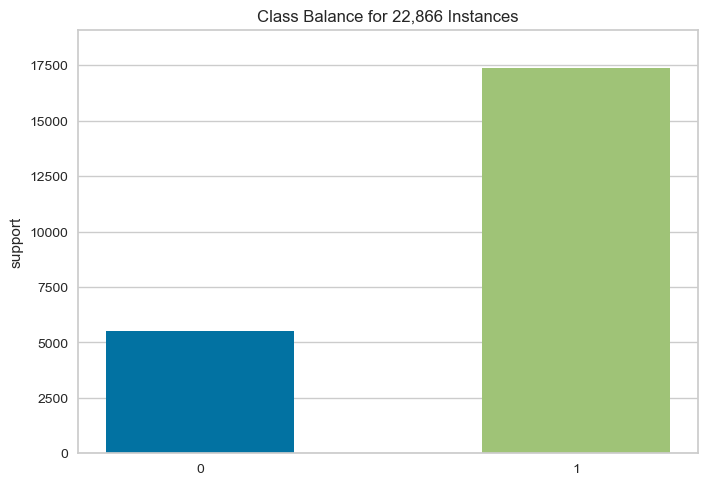

<AxesSubplot:title={'center':'Class Balance for 22,866 Instances'}, ylabel='support'>

In [8]:
visualizer = ClassBalance()
visualizer.fit(df['real'])  
visualizer.show() 

In [9]:
print(df['real'].value_counts(normalize=True) * 100)

1    75.968687
0    24.031313
Name: real, dtype: float64


После удаления пропусков выборка содержит 22 866 записей. Распределение классов не является сбалансированным: класс 1 составляет 76% выборки, а класс 0 — 24%. Полагаю, такую выборку можно обучить без дополнительных методов балансировки.

In [10]:
df['text'] = df[['title', 'news_url', 'source_domain']].agg(' '.join, axis=1)
df

,title,news_url,source_domain,tweet_num,real,text
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1,Kandi Burruss Explodes Over Rape Accusation on...
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1,People's Choice Awards 2018: The best red carp...
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1,Sophia Bush Sends Sweet Birthday Message to 'O...
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1,Colombian singer Maluma sparks rumours of inap...
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1,Gossip Girl 10 Years Later: How Upper East Sid...
...,...,...,...,...,...,...
23191,Pippa Middleton wedding: In case you missed it...,https://www.express.co.uk/news/royal/807049/pi...,www.express.co.uk,52,1,Pippa Middleton wedding: In case you missed it...
23192,Zayn Malik & Gigi Hadid’s Shocking Split: Why ...,hollywoodlife.com/2018/03/13/zayn-malik-gigi-h...,hollywoodlife.com,7,0,Zayn Malik & Gigi Hadid’s Shocking Split: Why ...
23193,Jessica Chastain Recalls the Moment Her Mother...,http://www.justjared.com/2018/01/17/jessica-ch...,www.justjared.com,26,1,Jessica Chastain Recalls the Moment Her Mother...
23194,"Tristan Thompson Feels ""Dumped"" After Khloé Ka...",www.intouchweekly.com/posts/tristan-thompson-f...,www.intouchweekly.com,24,0,"Tristan Thompson Feels ""Dumped"" After Khloé Ka..."


In [11]:
df[['text', 'real']].head()

,text,real
0,Kandi Burruss Explodes Over Rape Accusation on...,1
1,People's Choice Awards 2018: The best red carp...,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,1
3,Colombian singer Maluma sparks rumours of inap...,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,1


In [12]:
TEXT = 'text'
LABEL = 'real'

texts = df[TEXT].astype(str).tolist()  # текст берем из df['text']
labels = df[LABEL].astype(int).tolist()  # ответ/класс берем из df['real']

In [13]:
print(texts[0])
print(labels[0])

Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video) http://toofab.com/2017/05/08/real-housewives-atlanta-kandi-burruss-rape-phaedra-parks-porsha-williams/ toofab.com
1


In [14]:
type(texts)

list

### Токенизация

In [15]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    tokens = text.split()
    return tokens

tokenized_texts = [tokenize(text) for text in texts]

print(tokenized_texts[0])
print(labels[0])

['kandi', 'burruss', 'explodes', 'over', 'rape', 'accusation', 'on', 'real', 'housewives', 'of', 'atlanta', 'reunion', 'video', 'http', 'toofab', 'com', '2017', '05', '08', 'real', 'housewives', 'atlanta', 'kandi', 'burruss', 'rape', 'phaedra', 'parks', 'porsha', 'williams', 'toofab', 'com']
1


In [16]:
type(labels)

list

### Обучение Word2Vec

In [17]:
train_tokens, test_tokens, y_train, y_test = train_test_split(
    tokenized_texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)



w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,  # Размер эмбеддинга, каждый токен — это вектор из 100 чисел
    window=5,  # Сколько соседних слов учитывать
    min_count=2,  # Удалить слова, которые встретились один раз
    workers=4,
    sg=1, # sg=1 - Skip-Grram 
    seed=42,
    epochs=5
)


print(w2v_model.wv['news'][:10])
print(len(w2v_model.wv)) # w2v_model - объект модели, w2v_model.wv - словарь слов + их векторы

[ 0.3776799  -0.42680547  0.3101033  -0.5582582  -0.6389903  -0.17026831
 -0.31813595  0.41832033  0.07812662  0.17812313]
16787


In [18]:
word2idx = {
    word: idx
    for idx, word in enumerate(w2v_model.wv.index_to_key)
}

idx2word = {
    idx: word
    for word, idx in word2idx.items()
}

print(word2idx['news'])
print(idx2word[2])

7
https


In [19]:
PAD_IDX = 0

word2idx = {'<PAD>': PAD_IDX}

for word in w2v_model.wv.index_to_key:
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

### Формирование embedding_matrix

In [20]:
# Создаем матрицу нулей, Количество строк = количество слов в словаре, Количество столбцов = размерность вектора Word2Vec.
embedding_matrix = np.zeros(
    (len(word2idx), w2v_model.vector_size)
)

# Перебираем словарь: word - слово, idx - индекс этого слова
for word, idx in word2idx.items():
    if word != '<PAD>':
        # Получаем обученный вектор слова из Word2Vec и записываем его в строку с номером idx
        embedding_matrix[idx] = w2v_model.wv[word]
    
# Преобразуем массив в Tensor PyTorch, акой объект уже можно передавать в nn.Embedding
pretrained_embeddings = torch.FloatTensor(embedding_matrix)

print(embedding_matrix.shape)
print(pretrained_embeddings.shape)

(16788, 100)
torch.Size([16788, 100])


In [21]:
embedding_matrix

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.10029656,  0.18091618, -0.20904602, ...,  0.21787876,
        -0.20781484, -0.2144212 ],
       [ 0.19773461,  0.10939819, -0.28687906, ...,  0.08882003,
        -0.27139321,  0.18371868],
       ...,
       [-0.02544044, -0.11343658, -0.09243587, ...,  0.13007998,
        -0.09145338,  0.04459055],
       [-0.03213383, -0.08916943, -0.10827006, ...,  0.16037244,
        -0.07127465,  0.01521142],
       [ 0.00506502, -0.09128401, -0.07656487, ...,  0.07331975,
        -0.05556631,  0.0005336 ]])

In [22]:
def texts_to_indices(tokenized_rows, word2idx):
    indexed_rows = []

    for text in tokenized_rows:
        indices = []

        for word in text:
            if word in word2idx:
                indices.append(word2idx[word])

        indexed_rows.append(indices)

    return indexed_rows


train_indexed_texts = texts_to_indices(train_tokens, word2idx)
test_indexed_texts = texts_to_indices(test_tokens, word2idx)

print(train_indexed_texts[0])

[3221, 1192, 93, 19, 4170, 2701, 14, 342, 1903, 69, 7, 180, 203, 27, 212, 3692, 36, 5719, 3, 2, 30, 15, 17, 96, 34, 3221, 1192, 93, 4170, 2701, 342, 1903, 180, 203, 212, 3692, 5719, 24, 2, 30, 15, 17]


### Формирование padding последовательности

In [23]:
MAX_LEN = 100

train_lengths = np.array([
    max(1, min(len(indices), MAX_LEN))
    for indices in train_indexed_texts
])

test_lengths = np.array([
    max(1, min(len(indices), MAX_LEN))
    for indices in test_indexed_texts
])

X_train = pad_sequences(
    train_indexed_texts,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post',
    value=PAD_IDX
)

X_test = pad_sequences(
    test_indexed_texts,
    maxlen=MAX_LEN, # Максимум  слов в статье
    padding='post', # Добавлять нули в конец
    truncating='post',  # если статья длиннее, оставить первые 100 слов
    value=PAD_IDX
)

print(X_train.shape)
print(X_test.shape)
print(train_lengths[:10])

(18292, 100)
(4574, 100)
[42 24 30 29 21 35 34 35 37 33]


texts              # исходные тексты в строковом виде

tokenized_texts    # список токенов

indexed_texts      # список индексов переменной длины

padded_texts       # список индексов одинаковой длины (22866,100)

labels             # метки классов

In [24]:
# Переводим признаки в LongTensor. nn.Embedding принимает именно индексы слов типа long/int64.
# nn.Embedding expects word indices as int64/long tensors.
X_train_tensor = torch.LongTensor(X_train)
X_test_tensor = torch.LongTensor(X_test)

# RNN/LSTM/GRU will use these lengths to ignore right-side PAD tokens.
train_lengths_tensor = torch.LongTensor(train_lengths)
test_lengths_tensor = torch.LongTensor(test_lengths)

# BCEWithLogitsLoss expects float labels: 0.0 or 1.0.
y_train_tensor = torch.FloatTensor(y_train)
y_test_tensor = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, train_lengths_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, test_lengths_tensor, y_test_tensor)

BATCH_SIZE = 64

train_iterator = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_iterator = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch_texts, batch_lengths, batch_labels = next(iter(train_iterator))

print(batch_texts.shape)
print(batch_lengths.shape)
print(batch_labels.shape)

torch.Size([64, 100])
torch.Size([64])
torch.Size([64])


torch.Size([64,100])

т.е.:

64 статьи

в каждой статье

100 токенов

batch_labels.shape
torch.Size([64])

т.е.:

64 правильных ответа

0 или 1

In [25]:
# Создаем слой Embedding и загружаем в него готовые векторы Word2Vec
embedding = nn.Embedding.from_pretrained(
    pretrained_embeddings,
    freeze=False,  # Если False, то веса Embedding будут дополнительно изменяться во время обучения сети
    padding_idx=PAD_IDX
)

### модель RNN

In [26]:
# Создание класса RNN
class RNNClassifier(nn.Module):
    def __init__(self, embedding, hidden_size=128, num_layers=1, dropout=0.3):
        # Инициализация родительского класса nn.Module
        super().__init__()
        # Сохраняем Embedding
        self.embedding = embedding
        # Создаем RNN слой
        self.rnn = nn.RNN(
            # Размер входного вектора
            input_size=embedding.embedding_dim,
            # Размер скрытого состояния
            hidden_size=hidden_size,
            # Число слоев RNN
            num_layers=num_layers,
            # Батч первый: (batch, sequence, features)
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        # Финальный слой
        self.fc = nn.Linear(hidden_size, 1)
    # На вход приходит батч 

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, hidden = self.rnn(packed)
        last_hidden = hidden[-1]
        x = self.dropout(last_hidden)
        x = self.fc(x)
        return x.squeeze(1)

In [27]:
# Инициализация, 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Создаем модель
model = RNNClassifier(embedding).to(device)
# функция потерь для бинарной классификации
criterion = nn.BCEWithLogitsLoss()
# Создаем оптимизатор
optimizer = optim.Adam(model.parameters(), lr=0.001)

1. Сделали прогноз

2. Посчитали ошибку

3. Посчитали градиенты

4. Изменили веса

5. Ошибка уменьшилась

In [28]:
# Обучение и валидация
def train_one_epoch(model, iterator, criterion, optimizer, device):
    model.train()

    epoch_loss = 0
    all_preds = []
    all_labels = []

    for texts, lengths, labels in iterator:
        texts = texts.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(texts, lengths)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).int()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    return epoch_loss / len(iterator), acc


def evaluate(model, iterator, criterion, device):
    model.eval()

    epoch_loss = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, lengths, labels in iterator:
            texts = texts.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)

            outputs = model(texts, lengths)
            loss = criterion(outputs, labels)

            epoch_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).int()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    roc_auc = roc_auc_score(all_labels, all_probs)
    return epoch_loss / len(iterator), acc, f1, roc_auc, all_labels, all_probs
    #return epoch_loss / len(iterator), acc, f1, roc_auc

In [29]:
# Цикл обучения
num_epochs = 10

train_losses = []
test_losses = []

train_accs = []
test_accs = []

best_roc_auc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_iterator,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc, test_f1, test_roc_auc, _, _ = evaluate(
        model,
        test_iterator,
        criterion,
        device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f'Epoch {epoch + 1}/{num_epochs} | '
        f'Train loss: {train_loss:.4f} | '
        f'Train acc: {train_acc:.4f} | '
        f'Test loss: {test_loss:.4f} | '
        f'Test acc: {test_acc:.4f} | '
        f'F1: {test_f1:.4f} | '
        f'ROC AUC: {test_roc_auc:.4f}'
    )

    if test_roc_auc > best_roc_auc:
        best_roc_auc = test_roc_auc
        torch.save(model.state_dict(), 'rnn_model.pt')
        print('Best RNN model saved')

Epoch 1/10 | Train loss: 0.3616 | Train acc: 0.8573 | Test loss: 0.1933 | Test acc: 0.9471 | F1: 0.9661 | ROC AUC: 0.9478
Best RNN model saved
Epoch 2/10 | Train loss: 0.3337 | Train acc: 0.8753 | Test loss: 0.2547 | Test acc: 0.9187 | F1: 0.9487 | ROC AUC: 0.9009
Epoch 3/10 | Train loss: 0.1634 | Train acc: 0.9487 | Test loss: 0.1575 | Test acc: 0.9567 | F1: 0.9716 | ROC AUC: 0.9707
Best RNN model saved
Epoch 4/10 | Train loss: 0.1389 | Train acc: 0.9564 | Test loss: 0.1884 | Test acc: 0.9475 | F1: 0.9662 | ROC AUC: 0.9475
Epoch 5/10 | Train loss: 0.1023 | Train acc: 0.9703 | Test loss: 0.1290 | Test acc: 0.9622 | F1: 0.9754 | ROC AUC: 0.9675
Epoch 6/10 | Train loss: 0.0936 | Train acc: 0.9693 | Test loss: 0.1652 | Test acc: 0.9550 | F1: 0.9710 | ROC AUC: 0.9540
Epoch 7/10 | Train loss: 0.0858 | Train acc: 0.9748 | Test loss: 0.1844 | Test acc: 0.9462 | F1: 0.9651 | ROC AUC: 0.9555
Epoch 8/10 | Train loss: 0.0448 | Train acc: 0.9867 | Test loss: 0.2122 | Test acc: 0.9414 | F1: 0.9621 

In [30]:
rnn_loss, rnn_acc, rnn_f1, rnn_roc_auc, rnn_labels, rnn_probs = evaluate(
    model,
    test_iterator,
    criterion,
    device
)

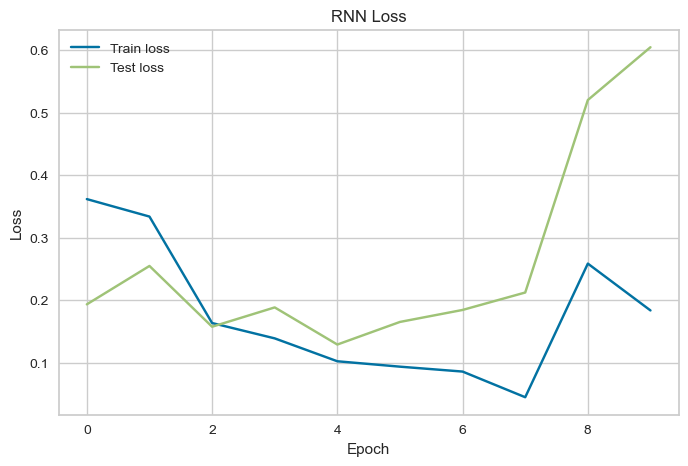

In [31]:
# График Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Loss')
plt.legend()
plt.show()

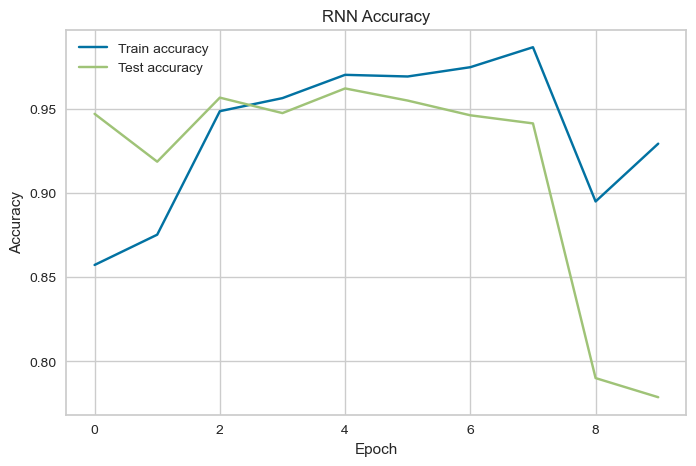

In [32]:
# График Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs, label='Train accuracy')
plt.plot(test_accs, label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('RNN Accuracy')
plt.legend()
plt.show()

In [33]:
# Финальные метрики RNN
test_loss, test_acc, test_f1, test_roc_auc, _, _ = evaluate(
    model,
    test_iterator,
    criterion,
    device
)

print('RNN final metrics:')
print(f'Accuracy: {test_acc:.4f}')
print(f'F1 Score: {test_f1:.4f}')
print(f'ROC AUC: {test_roc_auc:.4f}')



RNN final metrics:
Accuracy: 0.7787
F1 Score: 0.8553
ROC AUC: 0.7758


In [34]:
rnn_loss, rnn_acc, rnn_f1, rnn_roc_auc, rnn_labels, rnn_probs = evaluate(
    model,
    test_iterator,
    criterion,
    device
)

print('RNN final metrics:')
print(f'Accuracy: {rnn_acc:.4f}')
print(f'F1 Score: {rnn_f1:.4f}')
print(f'ROC AUC: {rnn_roc_auc:.4f}')

RNN final metrics:
Accuracy: 0.7787
F1 Score: 0.8553
ROC AUC: 0.7758


### LSTM/GRU

In [35]:
# новый Embedding, чтобы LSTM не использовала веса, уже измененные во время обучения RNN
embedding_lstm = nn.Embedding.from_pretrained(
    pretrained_embeddings,
    freeze=False,
    padding_idx=PAD_IDX
)


class LSTMClassifier(nn.Module):
    def __init__(self, embedding, hidden_size=128, num_layers=1, dropout=0.3):
        super().__init__()

        # Слой переводит индексы слов в векторы Word2Vec
        self.embedding = embedding

        # LSTM слой
        self.lstm = nn.LSTM(
            input_size=embedding.embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Dropout для регуляризации
        self.dropout = nn.Dropout(dropout)

        # Финальный слой бинарной классификации
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, (hidden, cell) = self.lstm(packed)
        last_hidden = hidden[-1]
        x = self.dropout(last_hidden)
        x = self.fc(x)
        return x.squeeze(1)


model_lstm = LSTMClassifier(embedding_lstm).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001)

In [36]:
num_epochs = 10

lstm_train_losses = []
lstm_test_losses = []

lstm_train_accs = []
lstm_test_accs = []

best_lstm_roc_auc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_lstm,
        train_iterator,
        criterion,
        optimizer_lstm,
        device
    )

    test_loss, test_acc, test_f1, test_roc_auc, _, _ = evaluate(
        model_lstm,
        test_iterator,
        criterion,
        device
    )

    lstm_train_losses.append(train_loss)
    lstm_test_losses.append(test_loss)

    lstm_train_accs.append(train_acc)
    lstm_test_accs.append(test_acc)

    print(
        f'Epoch {epoch + 1}/{num_epochs} | '
        f'Train loss: {train_loss:.4f} | '
        f'Train acc: {train_acc:.4f} | '
        f'Test loss: {test_loss:.4f} | '
        f'Test acc: {test_acc:.4f} | '
        f'F1: {test_f1:.4f} | '
        f'ROC AUC: {test_roc_auc:.4f}'
    )

    if test_roc_auc > best_lstm_roc_auc:
        best_lstm_roc_auc = test_roc_auc
        torch.save(model_lstm.state_dict(), 'lstm_model.pt')
        print('Best LSTM model saved')

Epoch 1/10 | Train loss: 0.1785 | Train acc: 0.9287 | Test loss: 0.0445 | Test acc: 0.9884 | F1: 0.9924 | ROC AUC: 0.9975
Best LSTM model saved
Epoch 2/10 | Train loss: 0.0219 | Train acc: 0.9944 | Test loss: 0.0453 | Test acc: 0.9891 | F1: 0.9928 | ROC AUC: 0.9977
Best LSTM model saved
Epoch 3/10 | Train loss: 0.0121 | Train acc: 0.9974 | Test loss: 0.0422 | Test acc: 0.9895 | F1: 0.9931 | ROC AUC: 0.9965
Epoch 4/10 | Train loss: 0.0087 | Train acc: 0.9979 | Test loss: 0.0472 | Test acc: 0.9886 | F1: 0.9925 | ROC AUC: 0.9972
Epoch 5/10 | Train loss: 0.0054 | Train acc: 0.9990 | Test loss: 0.0788 | Test acc: 0.9869 | F1: 0.9914 | ROC AUC: 0.9959
Epoch 6/10 | Train loss: 0.0037 | Train acc: 0.9991 | Test loss: 0.0575 | Test acc: 0.9871 | F1: 0.9916 | ROC AUC: 0.9943
Epoch 7/10 | Train loss: 0.0046 | Train acc: 0.9990 | Test loss: 0.0717 | Test acc: 0.9869 | F1: 0.9914 | ROC AUC: 0.9935
Epoch 8/10 | Train loss: 0.0150 | Train acc: 0.9969 | Test loss: 0.0587 | Test acc: 0.9904 | F1: 0.993

In [37]:
rnn_loss, rnn_acc, rnn_f1, rnn_roc_auc, rnn_labels, rnn_probs = evaluate(
    model,
    test_iterator,
    criterion,
    device
)

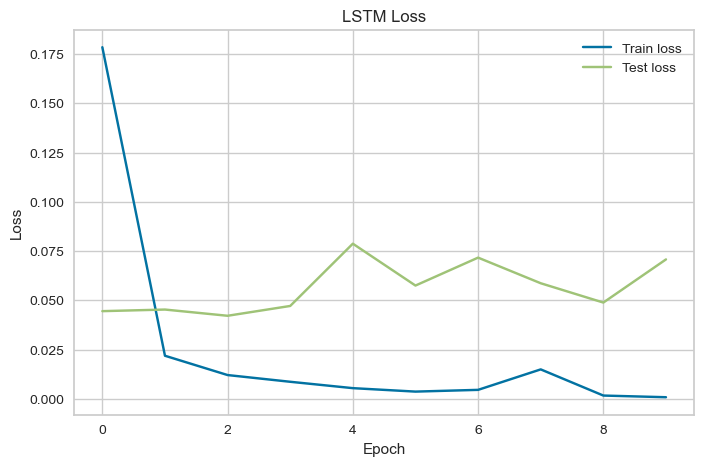

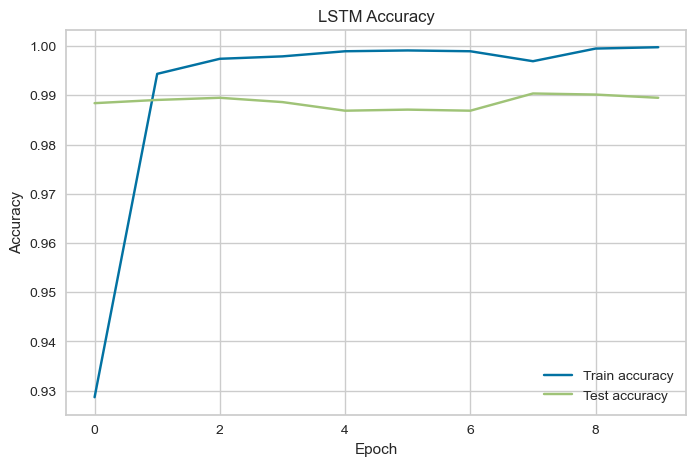

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(lstm_train_losses, label='Train loss')
plt.plot(lstm_test_losses, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(lstm_train_accs, label='Train accuracy')
plt.plot(lstm_test_accs, label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Accuracy')
plt.legend()
plt.show()

In [39]:
test_loss, test_acc, test_f1, test_roc_auc, _, _ = evaluate(
    model_lstm,
    test_iterator,
    criterion,
    device
)

print('LSTM final metrics:')
print(f'Accuracy: {test_acc:.4f}')
print(f'F1 Score: {test_f1:.4f}')
print(f'ROC AUC: {test_roc_auc:.4f}')

LSTM final metrics:
Accuracy: 0.9895
F1 Score: 0.9931
ROC AUC: 0.9980


In [40]:
lstm_loss, lstm_acc, lstm_f1, lstm_roc_auc, lstm_labels, lstm_probs = evaluate(
    model_lstm,
    test_iterator,
    criterion,
    device
)

print('LSTM final metrics:')
print(f'Accuracy: {lstm_acc:.4f}')
print(f'F1 Score: {lstm_f1:.4f}')
print(f'ROC AUC: {lstm_roc_auc:.4f}')

LSTM final metrics:
Accuracy: 0.9895
F1 Score: 0.9931
ROC AUC: 0.9980


In [41]:
embedding_gru = nn.Embedding.from_pretrained(
    pretrained_embeddings,
    freeze=False,
    padding_idx=PAD_IDX
)


class GRUClassifier(nn.Module):
    def __init__(self, embedding, hidden_size=128, num_layers=1, dropout=0.3):
        super().__init__()

        self.embedding = embedding

        self.gru = nn.GRU(
            input_size=embedding.embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, hidden = self.gru(packed)
        last_hidden = hidden[-1]
        x = self.dropout(last_hidden)
        x = self.fc(x)
        return x.squeeze(1)


model_gru = GRUClassifier(embedding_gru).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer_gru = optim.Adam(model_gru.parameters(), lr=0.001)

In [42]:
num_epochs = 10

gru_train_losses = []
gru_test_losses = []

gru_train_accs = []
gru_test_accs = []

best_gru_roc_auc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_gru,
        train_iterator,
        criterion,
        optimizer_gru,
        device
    )

    test_loss, test_acc, test_f1, test_roc_auc, _, _ = evaluate(
        model_gru,
        test_iterator,
        criterion,
        device
    )

    gru_train_losses.append(train_loss)
    gru_test_losses.append(test_loss)

    gru_train_accs.append(train_acc)
    gru_test_accs.append(test_acc)

    print(
        f'Epoch {epoch + 1}/{num_epochs} | '
        f'Train loss: {train_loss:.4f} | '
        f'Train acc: {train_acc:.4f} | '
        f'Test loss: {test_loss:.4f} | '
        f'Test acc: {test_acc:.4f} | '
        f'F1: {test_f1:.4f} | '
        f'ROC AUC: {test_roc_auc:.4f}'
    )

    if test_roc_auc > best_gru_roc_auc:
        best_gru_roc_auc = test_roc_auc
        torch.save(model_gru.state_dict(), 'gru_model.pt')
        print('Best GRU model saved')

Epoch 1/10 | Train loss: 0.0860 | Train acc: 0.9667 | Test loss: 0.0494 | Test acc: 0.9897 | F1: 0.9933 | ROC AUC: 0.9971
Best GRU model saved
Epoch 2/10 | Train loss: 0.0045 | Train acc: 0.9990 | Test loss: 0.0816 | Test acc: 0.9816 | F1: 0.9879 | ROC AUC: 0.9961
Epoch 3/10 | Train loss: 0.0123 | Train acc: 0.9968 | Test loss: 0.0670 | Test acc: 0.9869 | F1: 0.9914 | ROC AUC: 0.9978
Best GRU model saved
Epoch 4/10 | Train loss: 0.0034 | Train acc: 0.9990 | Test loss: 0.0546 | Test acc: 0.9864 | F1: 0.9911 | ROC AUC: 0.9981
Best GRU model saved
Epoch 5/10 | Train loss: 0.0013 | Train acc: 0.9996 | Test loss: 0.0713 | Test acc: 0.9858 | F1: 0.9907 | ROC AUC: 0.9977
Epoch 6/10 | Train loss: 0.0013 | Train acc: 0.9995 | Test loss: 0.0773 | Test acc: 0.9878 | F1: 0.9920 | ROC AUC: 0.9976
Epoch 7/10 | Train loss: 0.0007 | Train acc: 0.9997 | Test loss: 0.0643 | Test acc: 0.9889 | F1: 0.9927 | ROC AUC: 0.9980
Epoch 8/10 | Train loss: 0.0003 | Train acc: 0.9999 | Test loss: 0.0698 | Test acc:

In [43]:
rnn_loss, rnn_acc, rnn_f1, rnn_roc_auc, rnn_labels, rnn_probs = evaluate(
    model_gru,
    test_iterator,
    criterion,
    device
)

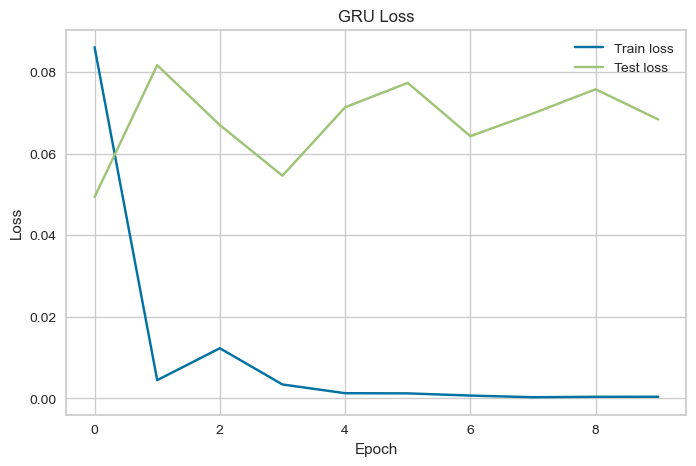

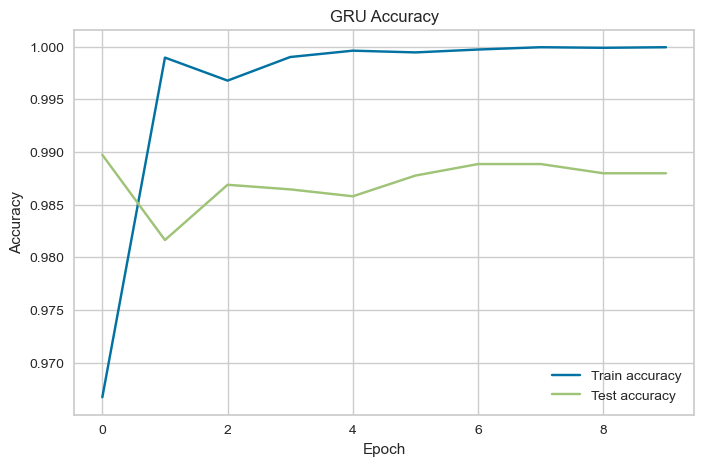

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(gru_train_losses, label='Train loss')
plt.plot(gru_test_losses, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(gru_train_accs, label='Train accuracy')
plt.plot(gru_test_accs, label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('GRU Accuracy')
plt.legend()
plt.show()

In [45]:
test_loss, test_acc, test_f1, test_roc_auc, _, _ = evaluate(
    model_gru,
    test_iterator,
    criterion,
    device
)

print('GRU final metrics:')
print(f'Accuracy: {test_acc:.4f}')
print(f'F1 Score: {test_f1:.4f}')
print(f'ROC AUC: {test_roc_auc:.4f}')

GRU final metrics:
Accuracy: 0.9880
F1 Score: 0.9921
ROC AUC: 0.9979


In [46]:
gru_loss, gru_acc, gru_f1, gru_roc_auc, gru_labels, gru_probs = evaluate(
    model_gru,
    test_iterator,
    criterion,
    device
)

print('GRU final metrics:')
print(f'Accuracy: {gru_acc:.4f}')
print(f'F1 Score: {gru_f1:.4f}')
print(f'ROC AUC: {gru_roc_auc:.4f}')

GRU final metrics:
Accuracy: 0.9880
F1 Score: 0.9921
ROC AUC: 0.9979


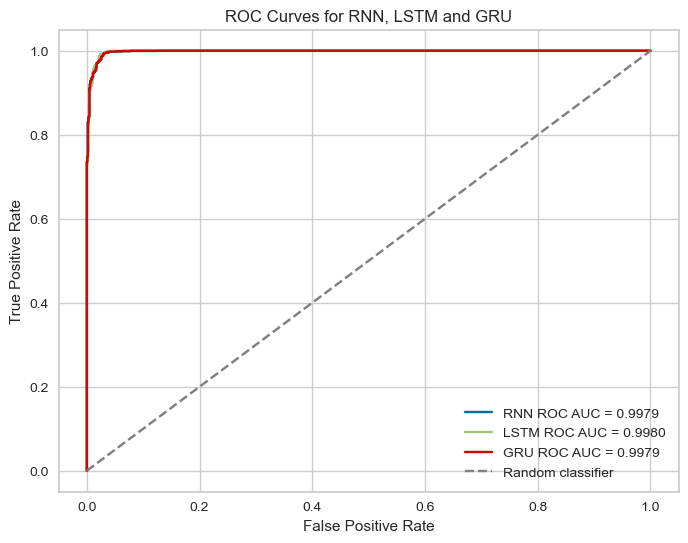

In [47]:
rnn_fpr, rnn_tpr, _ = roc_curve(rnn_labels, rnn_probs)
lstm_fpr, lstm_tpr, _ = roc_curve(lstm_labels, lstm_probs)
gru_fpr, gru_tpr, _ = roc_curve(gru_labels, gru_probs)

plt.figure(figsize=(8, 6))

plt.plot(rnn_fpr, rnn_tpr, label=f'RNN ROC AUC = {rnn_roc_auc:.4f}')
plt.plot(lstm_fpr, lstm_tpr, label=f'LSTM ROC AUC = {lstm_roc_auc:.4f}')
plt.plot(gru_fpr, gru_tpr, label=f'GRU ROC AUC = {gru_roc_auc:.4f}')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for RNN, LSTM and GRU')
plt.legend()
plt.grid(True)
plt.show()